##### ADRIÁN MARTINEZ BALEA & HUGO GARCÍA SOUTO

# MoNuSeg Image-to-Image Translation with Pix2Pix

In this project, we address an image-to-image translation task using the MoNuSeg dataset. Each sample is stored as a paired PNG image where the realistic histology image is placed on the left side and its corresponding label map is placed on the right side.

Our goal is to train a Pix2Pix-based model that receives a label map as input and generates a realistic histology image. In this first section, we set up the environment, define the dataset path, check reproducibility settings, and inspect the structure of the paired images before implementing the data pipeline.

Using device: cpu
Project root: /home/adrian/mia/q2/cv2/CV-II-PROJECT
Dataset directory: /home/adrian/mia/q2/cv2/CV-II-PROJECT/MoNuSeg
Number of PNG images found: 500
Sample file: image_001.png
Full paired image size: (400, 200)
Real image size: (200, 200)
Label map size: (200, 200)


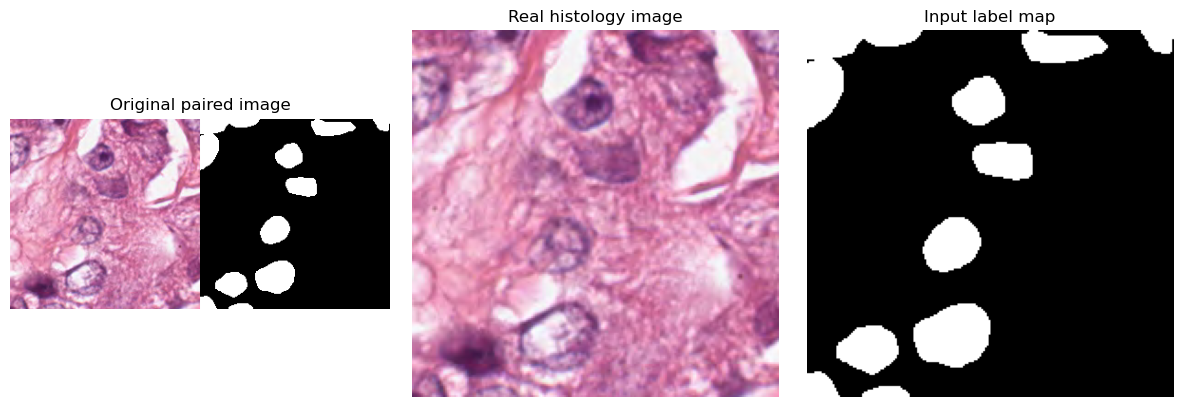

In [ ]:
# =========================
# 1. Project setup
# =========================

import torch
from pathlib import Path

from src.utils import (
    set_seed,
    get_device,
    get_image_paths,
    split_image_paths,
    show_original_paired_sample,
    show_paired_batch,
)

from src.datasets import create_dataloaders


SEED = 42
IMAGE_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 0

set_seed(SEED)

DEVICE = get_device()
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT.parent / "MoNuSeg"

image_paths = get_image_paths(DATASET_DIR)

print(f"Using device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DATASET_DIR}")
print(f"Number of PNG images found: {len(image_paths)}")

show_original_paired_sample(image_paths[0])

## Dataset Loading and Preprocessing

The MoNuSeg dataset contains 500 paired PNG images. Each file is composed of two horizontally concatenated images: the realistic histology image on the left and the corresponding label map on the right.

In this section, we implement a custom PyTorch dataset that automatically splits each paired image into input and target domains. The label map is used as the input image, while the realistic histology image is used as the target image. We resize both domains to 256 × 256 pixels to make the spatial dimensions compatible with the Pix2Pix generator and discriminator architectures.

For the baseline model, we only apply deterministic preprocessing: resizing, tensor conversion, and normalization to the range [-1, 1]. Data augmentation will be introduced later as part of the improvement stage.

Total images: 500
Training images: 350
Validation images: 75
Test images: 75


Input label batch shape: torch.Size([8, 3, 256, 256])
Target real batch shape: torch.Size([8, 3, 256, 256])
Example filenames: ['image_282.png', 'image_314.png', 'image_103.png', 'image_133.png']


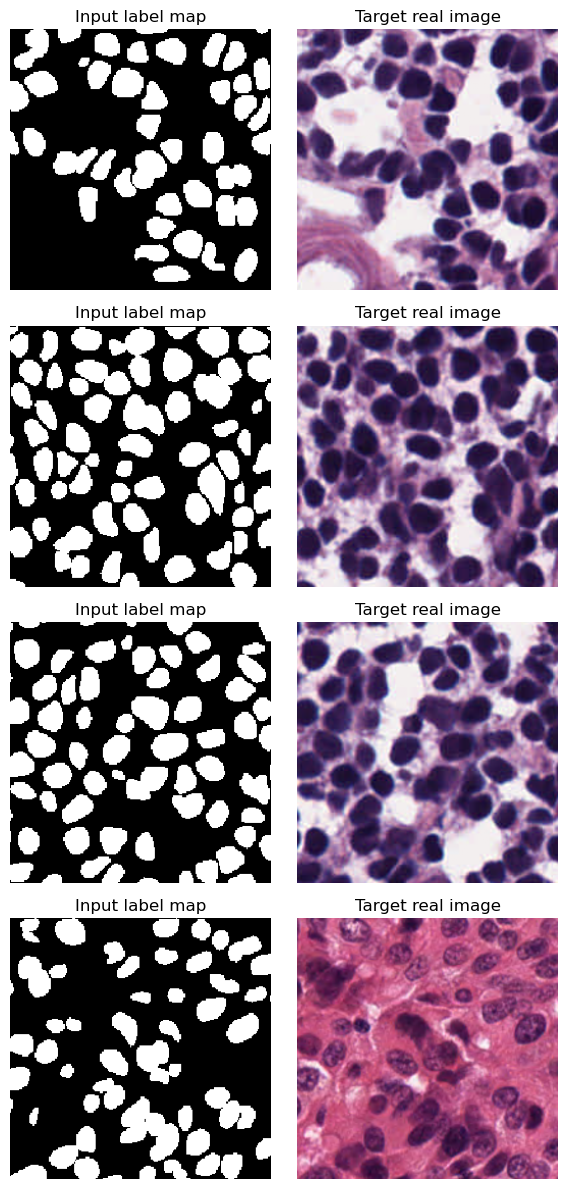

In [2]:
# =========================
# 2. Dataset loading and preprocessing
# =========================

train_paths, val_paths, test_paths = split_image_paths(
    image_paths=image_paths,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=SEED,
)

print(f"Total images: {len(image_paths)}")
print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images: {len(test_paths)}")

train_loader, val_loader, test_loader = create_dataloaders(
    train_paths=train_paths,
    val_paths=val_paths,
    test_paths=test_paths,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

batch = next(iter(train_loader))

print(f"Input label batch shape: {batch['label'].shape}")
print(f"Target real batch shape: {batch['real'].shape}")
print(f"Example filenames: {batch['filename'][:4]}")

show_paired_batch(batch, num_samples=4)

## Baseline Pix2Pix Architecture

In this section, we implement the baseline Pix2Pix architecture. The model follows the conditional GAN formulation, where the generator receives a label map and produces a realistic histology image. The discriminator receives both the input label map and either the real or generated image, and predicts whether local image patches are real or fake.

We use a U-Net generator because the skip connections help preserve spatial structure from the input label map. This is especially relevant for MoNuSeg, where the spatial arrangement of nuclei in the label map should guide the appearance of the generated histology image.

For the discriminator, we use a PatchGAN architecture. Instead of classifying the entire image as real or fake with a single scalar, PatchGAN classifies local patches. This encourages the generator to produce realistic local texture, which is important in histology images.

In [3]:
# =========================
# 3. Baseline Pix2Pix architecture
# =========================

from src.models import UNetGenerator, PatchGANDiscriminator
from src.utils import initialize_weights, count_parameters


BASE_CHANNELS = 64

generator = UNetGenerator(
    in_channels=3,
    out_channels=3,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

discriminator = PatchGANDiscriminator(
    in_channels=3,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

initialize_weights(generator)
initialize_weights(discriminator)


label_batch = batch["label"].to(DEVICE)
real_batch = batch["real"].to(DEVICE)

with torch.no_grad():
    fake_batch = generator(label_batch)
    discriminator_real_output = discriminator(label_batch, real_batch)
    discriminator_fake_output = discriminator(label_batch, fake_batch)

print(f"Generator parameters: {count_parameters(generator):,}")
print(f"Discriminator parameters: {count_parameters(discriminator):,}")
print(f"Input label batch shape: {label_batch.shape}")
print(f"Generated image batch shape: {fake_batch.shape}")
print(f"Discriminator real output shape: {discriminator_real_output.shape}")
print(f"Discriminator fake output shape: {discriminator_fake_output.shape}")

Generator parameters: 54,414,531
Discriminator parameters: 2,768,705
Input label batch shape: torch.Size([8, 3, 256, 256])
Generated image batch shape: torch.Size([8, 3, 256, 256])
Discriminator real output shape: torch.Size([8, 1, 30, 30])
Discriminator fake output shape: torch.Size([8, 1, 30, 30])


## Checkpoint Directory

Before running the full baseline training, we create the directory where all training checkpoints will be saved. The same directory will later be reused by the ablation experiments in Task 2, so that all model checkpoints (baseline plus four improved variants) live side by side and can be reloaded for the final test-set comparison.


In [4]:
# =========================
# 4. Checkpoint directory
# =========================

# All training checkpoints (baseline and improvements) will be saved here.
# The full baseline training configuration (learning rate, betas, lambda L1,
# number of epochs, optimizers, criteria) is defined directly in the full
# baseline training cell below.

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint directory: {CHECKPOINT_DIR}")

Checkpoint directory: /home/adrian/mia/q2/cv2/CV-II-PROJECT/checkpoints


## Full Baseline Training

In this section, we train the baseline Pix2Pix model from scratch.

We use the standard Pix2Pix configuration: Adam optimizer with learning rate 2e-4 and betas (0.5, 0.999), BCE-with-logits adversarial loss, L1 reconstruction loss with weight 100, and a batch size of 8. The generator loss combines the adversarial term (encourages realism) with the L1 term (preserves the structure and color distribution of the target histology image).

We monitor the validation L1 loss after each epoch and save two checkpoints: the last checkpoint and the best checkpoint according to validation performance. This baseline will serve as the reference model for the comparison with the improved approaches in Task 2.


In [5]:
# =========================
# 5. Full baseline training
# =========================

import time
import torch
import torch.nn as nn
import torch.optim as optim

from src.models import UNetGenerator, PatchGANDiscriminator
from src.training import train_pix2pix_one_epoch, validate_pix2pix, save_checkpoint
from src.utils import initialize_weights


# -------------------------
# Full baseline configuration
# -------------------------

BASE_CHANNELS = 64
LEARNING_RATE = 2e-4
BETA_1 = 0.5
BETA_2 = 0.999
LAMBDA_L1 = 100.0
NUM_EPOCHS_BASELINE = 30

BEST_BASELINE_CHECKPOINT_PATH = CHECKPOINT_DIR / "baseline_pix2pix_best.pt"
LAST_BASELINE_CHECKPOINT_PATH = CHECKPOINT_DIR / "baseline_pix2pix_last.pt"

print("Full baseline training configuration")
print(f"Base channels: {BASE_CHANNELS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Adam betas: ({BETA_1}, {BETA_2})")
print(f"Lambda L1: {LAMBDA_L1}")
print(f"Number of epochs: {NUM_EPOCHS_BASELINE}")
print(f"Best checkpoint path: {BEST_BASELINE_CHECKPOINT_PATH}")
print(f"Last checkpoint path: {LAST_BASELINE_CHECKPOINT_PATH}")


# -------------------------
# Reinitialize models
# -------------------------

generator = UNetGenerator(
    in_channels=3,
    out_channels=3,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

discriminator = PatchGANDiscriminator(
    in_channels=3,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

initialize_weights(generator)
initialize_weights(discriminator)

adversarial_criterion = nn.BCEWithLogitsLoss()
reconstruction_criterion = nn.L1Loss()

optimizer_g = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA_1, BETA_2),
)

optimizer_d = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA_1, BETA_2),
)


# -------------------------
# Training loop
# -------------------------

baseline_history = []
best_val_l1 = float("inf")

start_time = time.time()

for epoch in range(1, NUM_EPOCHS_BASELINE + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS_BASELINE}")

    train_metrics = train_pix2pix_one_epoch(
        generator=generator,
        discriminator=discriminator,
        dataloader=train_loader,
        optimizer_g=optimizer_g,
        optimizer_d=optimizer_d,
        adversarial_criterion=adversarial_criterion,
        reconstruction_criterion=reconstruction_criterion,
        device=DEVICE,
        lambda_l1=LAMBDA_L1,
    )

    val_metrics = validate_pix2pix(
        generator=generator,
        dataloader=val_loader,
        reconstruction_criterion=reconstruction_criterion,
        device=DEVICE,
    )

    epoch_metrics = {
        "epoch": epoch,
        **train_metrics,
        **val_metrics,
    }

    baseline_history.append(epoch_metrics)

    print(
        f"G loss: {epoch_metrics['generator_loss']:.4f} | "
        f"G adv: {epoch_metrics['generator_adversarial_loss']:.4f} | "
        f"G L1: {epoch_metrics['generator_l1_loss']:.4f} | "
        f"D loss: {epoch_metrics['discriminator_loss']:.4f} | "
        f"Val L1: {epoch_metrics['val_l1_loss']:.4f} | "
        f"Val PSNR: {epoch_metrics['val_psnr']:.2f} dB | "
        f"Val SSIM: {epoch_metrics['val_ssim']:.4f}"
    )

    # Save last checkpoint every epoch
    save_checkpoint(
        generator=generator,
        discriminator=discriminator,
        optimizer_g=optimizer_g,
        optimizer_d=optimizer_d,
        epoch=epoch,
        history=baseline_history,
        checkpoint_path=LAST_BASELINE_CHECKPOINT_PATH,
    )

    # Save best checkpoint based on validation L1
    if epoch_metrics["val_l1_loss"] < best_val_l1:
        best_val_l1 = epoch_metrics["val_l1_loss"]

        save_checkpoint(
            generator=generator,
            discriminator=discriminator,
            optimizer_g=optimizer_g,
            optimizer_d=optimizer_d,
            epoch=epoch,
            history=baseline_history,
            checkpoint_path=BEST_BASELINE_CHECKPOINT_PATH,
        )

        print(f"New best model saved with Val L1 = {best_val_l1:.4f}")

elapsed_time = time.time() - start_time

print(f"\nTraining completed in {elapsed_time / 60:.2f} minutes.")
print(f"Best validation L1 loss: {best_val_l1:.4f}")
print(f"Best checkpoint saved to: {BEST_BASELINE_CHECKPOINT_PATH}")
print(f"Last checkpoint saved to: {LAST_BASELINE_CHECKPOINT_PATH}")

Full baseline training configuration
Base channels: 64
Learning rate: 0.0002
Adam betas: (0.5, 0.999)
Lambda L1: 100.0
Number of epochs: 30
Best checkpoint path: /home/adrian/mia/q2/cv2/CV-II-PROJECT/checkpoints/baseline_pix2pix_best.pt
Last checkpoint path: /home/adrian/mia/q2/cv2/CV-II-PROJECT/checkpoints/baseline_pix2pix_last.pt

Epoch 1/30
Batch 010/044 | G: 31.3516 | G L1: 0.3056 | D: 0.7142
Batch 020/044 | G: 32.7689 | G L1: 0.3190 | D: 0.6490
Batch 030/044 | G: 32.8544 | G L1: 0.3188 | D: 0.7011
Batch 040/044 | G: 29.4297 | G L1: 0.2831 | D: 0.4971
Batch 044/044 | G: 32.0024 | G L1: 0.3095 | D: 0.5191
G loss: 32.0158 | G adv: 0.9435 | G L1: 0.3107 | D loss: 0.6863 | Val L1: 0.2902 | Val PSNR: 15.17 dB | Val SSIM: 0.4063
New best model saved with Val L1 = 0.2902

Epoch 2/30


KeyboardInterrupt: 

## Baseline Qualitative Results

After training the full baseline model, we inspect a few validation examples to qualitatively evaluate the generated histology images. We compare the input label map, the generated image, and the corresponding real target image.

This visual inspection is important because image-to-image translation quality cannot be fully assessed using a single scalar metric. In particular, we are interested in whether the generator preserves the nuclei layout from the label map and whether it produces realistic histological appearance in terms of color and texture.

In [ ]:
# =========================
# 6. Baseline qualitative results
# =========================

from src.utils import plot_training_history, show_generated_batch

plot_training_history(baseline_history)

show_generated_batch(
    generator=generator,
    dataloader=val_loader,
    device=DEVICE,
    num_samples=4,
)

## Baseline Test-Set Evaluation

Finally, we evaluate the best baseline checkpoint (selected on validation L1) on the held-out test set. This is the number we report in the baseline column of the comparison table in the final report.

We compute three complementary metrics:
- **L1 loss** in normalized space, which is the same training objective and is therefore directly comparable to training and validation curves.
- **PSNR** in decibels, computed in the [0, 1] image space. Higher is better.
- **SSIM** in the [0, 1] image space. Higher is better. SSIM is more aligned with human perception of structural similarity than L1 or PSNR.

In [ ]:
# =========================
# 7. Baseline test-set evaluation
# =========================

from src.training import load_generator_weights, evaluate_on_test_set


# Reload the best baseline checkpoint (selected on validation L1)
best_generator = UNetGenerator(
    in_channels=3,
    out_channels=3,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

best_generator = load_generator_weights(
    generator=best_generator,
    checkpoint_path=BEST_BASELINE_CHECKPOINT_PATH,
    device=DEVICE,
)

test_metrics = evaluate_on_test_set(
    generator=best_generator,
    test_loader=test_loader,
    device=DEVICE,
)

print("Baseline test-set results (best checkpoint by validation L1)")
print(f"  Test L1   : {test_metrics['test_l1_loss']:.4f}")
print(f"  Test PSNR : {test_metrics['test_psnr']:.2f} dB")
print(f"  Test SSIM : {test_metrics['test_ssim']:.4f}")

# Show a few qualitative examples from the test set for the report
show_generated_batch(
    generator=best_generator,
    dataloader=test_loader,
    device=DEVICE,
    num_samples=4,
)

# Task 2: Improvements (Ablation Study)

In this section, we evaluate three complementary improvements over the baseline Pix2Pix model and study their effect both **in isolation** and **combined**. The ablation design allows us to attribute any final gain to specific components, instead of reporting a single "improved" model whose gain could come from any combination.

The three improvements are:
- **Data augmentation** (synchronized flips, 90° rotations and mild color jitter on the real image). This attacks the overfitting we observed in the baseline (the validation L1 stopped improving after epoch 2 while the training L1 kept decreasing).
- **LSGAN adversarial loss** (Mao et al., 2017). The least-squares formulation provides smoother gradients than the standard BCE-with-logits loss and tends to stabilize GAN training. This is a change of one line in the loss definition.
- **Multi-scale PatchGAN discriminator** (two PatchGANs at full and half resolution). Adds a coarse-scale discriminator on top of the original fine-scale one. This encourages realism at both the fine texture and the broader structural level.

All models use the same data split, same seed, same number of epochs, same optimizer and same hyperparameters as the baseline. The only differences are the listed components. All five models are evaluated on the **same held-out test set** at the end.

Each model saves its own `best` and `last` checkpoints with distinct names so that none of them is overwritten.

## Generic Training Helper

Before launching the four new training runs, we encapsulate the full training loop in a single helper function. All experiments share the same structure, so a single helper avoids duplicating ~50 lines of code per model. The helper:
- Reinitializes generator and discriminator from scratch.
- Builds the requested adversarial criterion (`bce` or `lsgan`) and the requested discriminator (single-scale or multi-scale).
- Trains for `num_epochs`, validates after each epoch, and tracks the best checkpoint by validation L1.
- Returns the training history.

The same seed is set before every call to keep the comparison fair.

In [ ]:
# =========================
# 8. Generic training helper for the ablation study
# =========================

from src.models import UNetGenerator, PatchGANDiscriminator, MultiScalePatchGANDiscriminator
from src.training import (
    train_pix2pix_one_epoch,
    validate_pix2pix,
    save_checkpoint,
    load_generator_weights,
    evaluate_on_test_set,
    build_adversarial_criterion,
)
from src.utils import initialize_weights


def run_pix2pix_experiment(
    name: str,
    train_loader,
    val_loader,
    loss_type: str = "bce",
    use_multiscale_d: bool = False,
    num_epochs: int = 30,
    base_channels: int = 64,
    learning_rate: float = 2e-4,
    betas: tuple = (0.5, 0.999),
    lambda_l1: float = 100.0,
    seed: int = 42,
):
    """
    Train one ablation variant and return (history, best_checkpoint_path).
    """
    print(f"\n{'=' * 70}")
    print(f"Experiment: {name}")
    print(f"  loss_type = {loss_type}, multi_scale_d = {use_multiscale_d}")
    print(f"  epochs = {num_epochs}, lambda_l1 = {lambda_l1}")
    print(f"{'=' * 70}")

    # Reset seeds for every experiment so they all start from the same point
    set_seed(seed)

    # Build models
    generator = UNetGenerator(
        in_channels=3, out_channels=3, base_channels=base_channels
    ).to(DEVICE)

    if use_multiscale_d:
        discriminator = MultiScalePatchGANDiscriminator(
            in_channels=3, base_channels=base_channels, num_scales=2
        ).to(DEVICE)
    else:
        discriminator = PatchGANDiscriminator(
            in_channels=3, base_channels=base_channels
        ).to(DEVICE)

    initialize_weights(generator)
    initialize_weights(discriminator)

    # Optim and losses
    adversarial_criterion = build_adversarial_criterion(loss_type)
    reconstruction_criterion = nn.L1Loss()

    optimizer_g = optim.Adam(generator.parameters(), lr=learning_rate, betas=betas)
    optimizer_d = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=betas)

    best_ckpt = CHECKPOINT_DIR / f"{name}_best.pt"
    last_ckpt = CHECKPOINT_DIR / f"{name}_last.pt"

    history = []
    best_val_l1 = float("inf")
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_metrics = train_pix2pix_one_epoch(
            generator=generator,
            discriminator=discriminator,
            dataloader=train_loader,
            optimizer_g=optimizer_g,
            optimizer_d=optimizer_d,
            adversarial_criterion=adversarial_criterion,
            reconstruction_criterion=reconstruction_criterion,
            device=DEVICE,
            lambda_l1=lambda_l1,
        )

        val_metrics = validate_pix2pix(
            generator=generator,
            dataloader=val_loader,
            reconstruction_criterion=reconstruction_criterion,
            device=DEVICE,
        )

        epoch_metrics = {"epoch": epoch, **train_metrics, **val_metrics}
        history.append(epoch_metrics)

        print(
            f"G loss: {epoch_metrics['generator_loss']:.4f} | "
            f"G adv: {epoch_metrics['generator_adversarial_loss']:.4f} | "
            f"G L1: {epoch_metrics['generator_l1_loss']:.4f} | "
            f"D loss: {epoch_metrics['discriminator_loss']:.4f} | "
            f"Val L1: {epoch_metrics['val_l1_loss']:.4f} | "
            f"Val PSNR: {epoch_metrics['val_psnr']:.2f} dB | "
            f"Val SSIM: {epoch_metrics['val_ssim']:.4f}"
        )

        save_checkpoint(
            generator=generator,
            discriminator=discriminator,
            optimizer_g=optimizer_g,
            optimizer_d=optimizer_d,
            epoch=epoch,
            history=history,
            checkpoint_path=last_ckpt,
        )

        if epoch_metrics["val_l1_loss"] < best_val_l1:
            best_val_l1 = epoch_metrics["val_l1_loss"]
            save_checkpoint(
                generator=generator,
                discriminator=discriminator,
                optimizer_g=optimizer_g,
                optimizer_d=optimizer_d,
                epoch=epoch,
                history=history,
                checkpoint_path=best_ckpt,
            )
            print(f"  -> New best model saved (Val L1 = {best_val_l1:.4f})")

    elapsed = (time.time() - start_time) / 60.0
    print(f"\nExperiment '{name}' completed in {elapsed:.2f} min.")
    print(f"Best Val L1: {best_val_l1:.4f}")
    print(f"Best checkpoint: {best_ckpt}")

    return history, best_ckpt

## Augmented Training DataLoader

Augmentations are applied only to the training set. The validation and test loaders defined at the top of the notebook are reused as-is, so all five models are evaluated on exactly the same val/test images.

In [ ]:
# =========================
# 9. Augmented training DataLoader (shared by aug-based experiments)
# =========================

from src.datasets import create_dataloaders_aug

train_loader_aug, _, _ = create_dataloaders_aug(
    train_paths=train_paths,
    val_paths=val_paths,
    test_paths=test_paths,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# Sanity check: inspect a batch with augmentations applied
aug_batch = next(iter(train_loader_aug))
print(f"Augmented train batch shape: {aug_batch['label'].shape}")
show_paired_batch(aug_batch, num_samples=4)

## Improvement 1: + Augmentation

Same architecture, same losses and same hyperparameters as the baseline. The only change is the training DataLoader, which now applies synchronized augmentations (flips, 90° rotations) and mild color jitter on the real image only. Because data augmentation effectively increases the diversity seen by the generator, we expect overfitting to be reduced and validation metrics to improve.

In [ ]:
# =========================
# 10. Improvement 1: + Augmentation
# =========================

history_aug, ckpt_aug = run_pix2pix_experiment(
    name="improved_aug",
    train_loader=train_loader_aug,
    val_loader=val_loader,
    loss_type="bce",
    use_multiscale_d=False,
    num_epochs=NUM_EPOCHS_BASELINE,
)

plot_training_history(history_aug)

## Improvement 2: + LSGAN Loss

Same baseline data (no augmentations) and same architecture, but the adversarial criterion is changed from `BCEWithLogitsLoss` to `MSELoss`. This is the Least Squares GAN formulation (Mao et al., 2017). Intuitively, LSGAN penalizes how far the discriminator output is from the target label, which gives non-saturating gradients and tends to stabilize the training dynamics. This isolates the effect of the loss change.

In [ ]:
# =========================
# 11. Improvement 2: + LSGAN loss
# =========================

history_lsgan, ckpt_lsgan = run_pix2pix_experiment(
    name="improved_lsgan",
    train_loader=train_loader,
    val_loader=val_loader,
    loss_type="lsgan",
    use_multiscale_d=False,
    num_epochs=NUM_EPOCHS_BASELINE,
)

plot_training_history(history_lsgan)

## Improvement 3: + Multi-scale Discriminator

Same baseline data (no augmentations) and same loss (BCE). The single-scale PatchGAN is replaced by a multi-scale PatchGAN with two scales: full resolution and 1/2 resolution. The adversarial loss is averaged across the two discriminators. This isolates the effect of the discriminator architecture.

In [ ]:
# =========================
# 12. Improvement 3: + Multi-scale discriminator
# =========================

history_multi, ckpt_multi = run_pix2pix_experiment(
    name="improved_multi",
    train_loader=train_loader,
    val_loader=val_loader,
    loss_type="bce",
    use_multiscale_d=True,
    num_epochs=NUM_EPOCHS_BASELINE,
)

plot_training_history(history_multi)

## Improvement 4: All Combined (Augmentation + LSGAN + Multi-scale D)

Final improved model with all three components active simultaneously. Comparing this against the three isolated improvements tells us whether the components are complementary (the combined gain is close to the sum of individual gains) or partially redundant (the combined gain is less than the sum).

In [ ]:
# =========================
# 13. Improvement 4: combined improved model
# =========================

history_all, ckpt_all = run_pix2pix_experiment(
    name="improved_all",
    train_loader=train_loader_aug,
    val_loader=val_loader,
    loss_type="lsgan",
    use_multiscale_d=True,
    num_epochs=NUM_EPOCHS_BASELINE,
)

plot_training_history(history_all)

## Ablation Comparison on the Test Set

Final test-set evaluation of all five models (baseline + the four improved variants). All five are evaluated with their best checkpoint (selected by validation L1) on exactly the same test images.

Reading the table:
- The first three improved rows isolate the effect of one component at a time.
- The last row combines all three components and is the model we recommend as the final improved system.
- L1 is lower-is-better; PSNR (dB) and SSIM are higher-is-better.

In [ ]:
# =========================
# 14. Ablation comparison on the test set
# =========================

import pandas as pd


def evaluate_checkpoint_on_test(
    ckpt_path,
    use_multiscale_d_for_loading=False,  # only G is loaded, D is irrelevant here
):
    """Build a generator with the right shape, load weights, evaluate on test."""
    g = UNetGenerator(
        in_channels=3, out_channels=3, base_channels=BASE_CHANNELS
    ).to(DEVICE)
    g = load_generator_weights(g, ckpt_path, DEVICE)
    return evaluate_on_test_set(g, test_loader, DEVICE), g


experiments = [
    ("Baseline", BEST_BASELINE_CHECKPOINT_PATH, False),
    ("+ Augmentation", ckpt_aug, False),
    ("+ LSGAN", ckpt_lsgan, False),
    ("+ Multi-scale D", ckpt_multi, True),
    ("Improved (all)", ckpt_all, True),
]

rows = []
generators_by_name = {}

for name, ckpt_path, use_multi_d in experiments:
    test_metrics, g = evaluate_checkpoint_on_test(ckpt_path, use_multi_d)
    rows.append(
        {
            "Model": name,
            "Test L1": round(test_metrics["test_l1_loss"], 4),
            "Test PSNR (dB)": round(test_metrics["test_psnr"], 2),
            "Test SSIM": round(test_metrics["test_ssim"], 4),
        }
    )
    generators_by_name[name] = g

results_df = pd.DataFrame(rows)
print("Test-set ablation results")
print(results_df.to_string(index=False))

# Save to CSV for the report
results_path = PROJECT_ROOT / "ablation_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")

## Qualitative Side-by-side Comparison

For the report, we visualize the same test-set examples generated by all five models, alongside the input label map and the ground-truth real image. This makes it easy to see qualitative differences between models that may not be fully captured by a single scalar metric.

In [ ]:
# =========================
# 15. Qualitative side-by-side comparison
# =========================

import matplotlib.pyplot as plt
from src.utils import denormalize_image


def compare_models_qualitatively(
    generators_by_name: dict,
    test_loader,
    device,
    num_samples: int = 3,
):
    """Plot, for each test example, label / each model's output / ground truth."""
    batch = next(iter(test_loader))
    labels = batch["label"][:num_samples].to(device)
    reals = batch["real"][:num_samples].to(device)

    model_names = list(generators_by_name.keys())
    num_models = len(model_names)
    num_cols = 2 + num_models  # label + each model + real

    fig, axes = plt.subplots(
        num_samples, num_cols, figsize=(3 * num_cols, 3 * num_samples)
    )
    if num_samples == 1:
        axes = axes[None, :]

    # Pre-compute generations for each model
    with torch.no_grad():
        outputs_per_model = {
            name: generators_by_name[name](labels) for name in model_names
        }

    label_np = denormalize_image(labels).cpu()
    real_np = denormalize_image(reals).cpu()

    for row in range(num_samples):
        # Column 0: label
        axes[row, 0].imshow(label_np[row].permute(1, 2, 0))
        axes[row, 0].set_title("Label map" if row == 0 else "")
        axes[row, 0].axis("off")

        # Columns 1..N: each model's generation
        for col, name in enumerate(model_names, start=1):
            out = denormalize_image(outputs_per_model[name]).cpu()
            axes[row, col].imshow(out[row].permute(1, 2, 0))
            axes[row, col].set_title(name if row == 0 else "")
            axes[row, col].axis("off")

        # Last column: real
        axes[row, -1].imshow(real_np[row].permute(1, 2, 0))
        axes[row, -1].set_title("Real (ground truth)" if row == 0 else "")
        axes[row, -1].axis("off")

    plt.tight_layout()
    fig_path = PROJECT_ROOT / "qualitative_comparison.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to: {fig_path}")


compare_models_qualitatively(
    generators_by_name=generators_by_name,
    test_loader=test_loader,
    device=DEVICE,
    num_samples=3,
)